In [1]:
#bert-base-multilingual-uncased
#https://mccormickml.com/2019/07/22/BERT-fine-tuning/
import tensorflow as tf

# Get the GPU device name.
device_name = tf.test.gpu_device_name()

# The device name should look like the following:
if device_name == '/device:GPU:0':
    print('Found GPU at: {}'.format(device_name))
else:
    raise SystemError('GPU device not found')

Found GPU at: /device:GPU:0


In [ ]:
#!pip install torch
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla T4


In [ ]:
!pip install transformers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the dataset into a pandas dataframe.
df =  pd.read_csv("/content/drive/MyDrive/reviews.csv", encoding='UTF8', sep="\t")
df = df.dropna()
df.dropna(subset = ['review'])
# Report the number of reviews.
print('Number of training reviews: {:,}\n'.format(df.shape[0]))

# Display 10 random rows from the data.
df.tail(10)

Number of training reviews: 90,000



,review,sentiment
89990,"Неплохой топик, но без белья носить не очень к...",positive
89991,За 662 руб отличный вариант. Был сильный прелы...,positive
89992,супер быстрая доставка,positive
89993,"Пришли быстро, на ощупь очень приятные. Реко...",positive
89994,Леги просто СУПЕРРР!!!,positive
89995,сделано достаточно хорошо. на ткани сделан рис...,positive
89996,Накидка шикарная. Спасибо большое провдо линяе...,positive
89997,спасибо большое ) продовца рекомендую.. заказа...,positive
89998,Очень довольна заказом! Меньше месяца в РБ. К...,positive
89999,хорошая куртка. постороннего запаха нет. швы р...,positive


In [ ]:
import re
# Удаление эмодзи
def emoji(string):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', string)
#Удаление URL

def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)
#Удаление HTML-тегов
from bs4 import BeautifulSoup
#Function for removing html
def html(text):
    return BeautifulSoup(text, "lxml").text

In [ ]:
#df = df.drop(df[df.sentiment == "neautral"].index)
# сохраняем нейтральные отзывы в датафрейме
df = df.dropna()
df = df.reset_index(drop=True)

In [ ]:
df = df.sample(frac=1)
df = df.head(3000) # ограничение выборки
df.head(10)

,review,sentiment
52910,"Рубашка хорошая, с размером все в порядке, пра...",neautral
42125,"Очень прилипают к ногам, ооооочень",neautral
78860,"Хорошее , понравилось",positive
79307,"Классная пижама,на 44 размер заказала м.села и...",positive
25204,"Товар так и не пришёл,попросила вернуть деньги...",negative
13405,"ужас, платье зачем то заталированное слишком, ...",negative
28190,Товар не пришел. Больше двух месяцев ждала. За...,negative
84747,хорошо все подошло и цвет и размер,positive
88356,На размер 40/42 размер М подошёл отлично. На р...,positive
58622,"совсем не то, что в описании,цвет хаки,но не с...",neautral


In [ ]:
# Get the lists of sentences and their labels.
def categorise(row):
    if row['sentiment'] == 'negative':
        return 0
    elif row['sentiment'] == 'neautral':
        return 1
    elif row['sentiment'] == 'positive':
        return 2
# df=df.dropna()
# df = df[df['sentiment'] != 'neautral']
df['text_ready'] = df['review'].apply(emoji)
df['text_ready'] = df['text_ready'].apply(remove_urls)
df['text_ready'] = df['text_ready'].apply(html)
df[['text_ready']].head()
df['labels'] = df.apply(lambda row: categorise(row), axis=1)

In [ ]:
df.sample(10)

,review,sentiment,text_ready,labels
5722,Заказ мной не был получен !!!! Заказ ушел в др...,negative,Заказ мной не был получен !!!! Заказ ушел в др...,0
58648,доставка была очень долгой,neautral,доставка была очень долгой,1
41176,"Наконец таки товар пришёл, ждала больше трёх ...",neautral,"Наконец таки товар пришёл, ждала больше трёх ...",1
49603,ужасное качество.,neautral,ужасное качество.,1
44604,"Не соответствует размер,а так качество не плох...",neautral,"Не соответствует размер,а так качество не плох...",1
43586,рукава короткие,neautral,рукава короткие,1
54645,куртка смотрится дешево,neautral,куртка смотрится дешево,1
77135,На 92-65-93 и рост 166 подошли. Доставка быстрая,positive,На 92-65-93 и рост 166 подошли. Доставка быстрая,2
62221,"Хороший кардиган, тёплый. На рост 170 чуть выш...",positive,"Хороший кардиган, тёплый. На рост 170 чуть выш...",2
8310,"прислали не тот размер,деньги возвращать отказ...",negative,"прислали не тот размер,деньги возвращать отказ...",0


In [ ]:
df.head(10)

,review,sentiment,text_ready,labels
52910,"Рубашка хорошая, с размером все в порядке, пра...",neautral,"Рубашка хорошая, с размером все в порядке, пра...",1
42125,"Очень прилипают к ногам, ооооочень",neautral,"Очень прилипают к ногам, ооооочень",1
78860,"Хорошее , понравилось",positive,"Хорошее , понравилось",2
79307,"Классная пижама,на 44 размер заказала м.села и...",positive,"Классная пижама,на 44 размер заказала м.села и...",2
25204,"Товар так и не пришёл,попросила вернуть деньги...",negative,"Товар так и не пришёл,попросила вернуть деньги...",0
13405,"ужас, платье зачем то заталированное слишком, ...",negative,"ужас, платье зачем то заталированное слишком, ...",0
28190,Товар не пришел. Больше двух месяцев ждала. За...,negative,Товар не пришел. Больше двух месяцев ждала. За...,0
84747,хорошо все подошло и цвет и размер,positive,хорошо все подошло и цвет и размер,2
88356,На размер 40/42 размер М подошёл отлично. На р...,positive,На размер 40/42 размер М подошёл отлично. На р...,2
58622,"совсем не то, что в описании,цвет хаки,но не с...",neautral,"совсем не то, что в описании,цвет хаки,но не с...",1


In [ ]:
df.loc[df.labels == 0].sample(5)[['text_ready', 'labels']]

,text_ready,labels
1265,Очень маленькая,0
25947,7 июня была оплата заказа - сегодня 15 октября...,0
19460,Товар не пришёл!деньги не вернули!!!,0
19787,"ждала заказ 4 месяца,но так и не дождалась!3 р...",0
2983,Материал не соответствует материалу таких же т...,0


In [ ]:
# Get the lists of sentences and their labels.
sentences = df.text_ready.values
labels = df.labels.values

In [ ]:
from transformers import BertTokenizer

# Load the BERT tokenizer.
print('Loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased', do_lower_case=True)

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

In [ ]:
max_len = 0

# For every sentence...
for sent in sentences:

    # Tokenize the text and add `[CLS]` and `[SEP]` tokens.
    input_ids = tokenizer.encode(sent, add_special_tokens=True)

    # Update the maximum sentence length.
    max_len = max(max_len, len(input_ids))

print('Max sentence length: ', max_len)

Max sentence length:  343


In [ ]:
input_ids = []
attention_masks = []

# For every sentence...
for sent in sentences:
    # `tokenizer()` will:
    #   (1) Tokenize the sentence.
    #   (2) Prepend the `[CLS]` token to the start.
    #   (3) Append the `[SEP]` token to the end.
    #   (4) Map tokens to their IDs.
    #   (5) Pad or truncate the sentence to `max_length`
    #   (6) Create attention masks for [PAD] tokens.
    encoded_dict = tokenizer(
                        sent,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        max_length = 64,           # Pad & truncate all sentences.
                        padding='max_length',      # Pad to max_length.
                        truncation=True,           # Truncate to max_length.
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )

    # Add the encoded sentence to the list.
    input_ids.append(encoded_dict['input_ids'])

    # And its attention mask (simply differentiates padding from non-padding).
    attention_masks.append(encoded_dict['attention_mask'])

# Convert the lists into tensors.
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels)

# Print sentence 0, now as a list of IDs.
print('Original: ', sentences[0])
print('Token IDs:', input_ids[0])

Original:  Рубашка хорошая, с размером все в порядке, прада, чуть-чуть маловата, химозного запаха не было,шла долго, заказала чёрную и каково было моё удивление, когда я получила не просто чёрную, а чёрную с темно синими полосами, да ещё по середине белой линии идёт жёлтая полоска, так что фотография не соответствует действительности, и плюс последняя пуговица пришита наизнанку, но в целом заказом довольна, даже этим неожиданнастям, кто не боится получить фиг знает что советую.
Token IDs: tensor([  101, 78148, 13634, 20971, 73855, 47233, 14926,   117,   323, 56534,
        10392, 12506,   309, 63311,   117, 33072, 11056,   117, 90315,   118,
        90315, 30725, 51695,   117,   327, 13902, 45824, 11261, 10242, 85443,
        10185, 10396, 11769,   117,   330, 10726, 90906,   117, 10242, 46556,
        15766, 15097, 51249, 15029,   315, 12708, 14884, 11769, 74584, 10226,
          325, 94107, 18596,   117, 14321,   337, 30312, 10396, 30089, 15097,
        51249, 15029,   117,   102])


In [ ]:
from torch.utils.data import TensorDataset, random_split

# Combine the training inputs into a TensorDataset.
dataset = TensorDataset(input_ids, attention_masks, labels)

# Create a 90-10 train-validation split.

# Calculate the number of samples to include in each set.
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

# Divide the dataset by randomly selecting samples.
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print('{:>5,} training samples'.format(train_size))
print('{:>5,} validation samples'.format(val_size))

2,700 training samples
  300 validation samples


In [ ]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# The DataLoader needs to know our batch size for training, so we specify it
# here. For fine-tuning BERT on a specific task, the authors recommend a batch
# size of 16 or 32.
batch_size = 32

# Create the DataLoaders for our training and validation sets.
# We'll take training samples in random order.
train_dataloader = DataLoader(
            train_dataset,  # The training samples.
            sampler = RandomSampler(train_dataset), # Select batches randomly
            batch_size = batch_size # Trains with this batch size.
        )

# For validation the order doesn't matter, so we'll just read them sequentially.
validation_dataloader = DataLoader(
            val_dataset, # The validation samples.
            sampler = SequentialSampler(val_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

In [ ]:
from transformers import BertForSequenceClassification, BertConfig

# Load BertForSequenceClassification, the pretrained BERT model with a single
# linear classification layer on top.
model = BertForSequenceClassification.from_pretrained(
    "bert-base-multilingual-uncased",
    num_labels = 3, # Меняем количество классов на 3 (positive, negative, neautral)
                    # You can increase this for multi-class tasks.
    output_attentions = False, # Whether the model returns attentions weights.
    output_hidden_states = False, # Whether the model returns all hidden-states.
)

# Tell pytorch to run this model on the GPU.
model.cuda()

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [ ]:
from torch.optim import AdamW

In [ ]:
# Get all of the model's parameters as a list of tuples.
params = list(model.named_parameters())

print('The BERT model has {:} different named parameters.\n'.format(len(params)))

print('==== Embedding Layer ====\n')

for p in params[0:5]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

print('\n==== First Transformer ====\n')

for p in params[5:21]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

print('\n==== Output Layer ====\n')

for p in params[-4:]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

The BERT model has 201 different named parameters.

==== Embedding Layer ====

bert.embeddings.word_embeddings.weight                  (105879, 768)
bert.embeddings.position_embeddings.weight                (512, 768)
bert.embeddings.token_type_embeddings.weight                (2, 768)
bert.embeddings.LayerNorm.weight                              (768,)
bert.embeddings.LayerNorm.bias                                (768,)

==== First Transformer ====

bert.encoder.layer.0.attention.self.query.weight          (768, 768)
bert.encoder.layer.0.attention.self.query.bias                (768,)
bert.encoder.layer.0.attention.self.key.weight            (768, 768)
bert.encoder.layer.0.attention.self.key.bias                  (768,)
bert.encoder.layer.0.attention.self.value.weight          (768, 768)
bert.encoder.layer.0.attention.self.value.bias                (768,)
bert.encoder.layer.0.attention.output.dense.weight        (768, 768)
bert.encoder.layer.0.attention.output.dense.bias              

In [ ]:
# Note: AdamW is a class from the huggingface library (as opposed to pytorch)
# I believe the 'W' stands for 'Weight Decay fix"
optimizer = AdamW(model.parameters(),
                  lr = 2e-5, # args.learning_rate - default is 5e-5, our notebook had 2e-5
                  eps = 1e-8 # args.adam_epsilon  - default is 1e-8.
                )


In [ ]:
from transformers import get_linear_schedule_with_warmup

# Number of training epochs. The BERT authors recommend between 2 and 4.
epochs = 3

# Total number of training steps is [number of batches] x [number of epochs].
# (Note that this is not the same as the number of training samples).
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)

In [ ]:
import numpy as np

# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [ ]:
import time
import datetime

def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))

    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))


In [ ]:
import random
import numpy as np

# This training code is based on the `run_glue.py` script here:
# https://github.com/huggingface/transformers/blob/5bfcd0485ece086ebcbed2d008813037968a9e58/examples/run_glue.py#L128

# Set the seed value all over the place to make this reproducible.
seed_val = 34

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

# We'll store a number of quantities such as training and validation loss,
# validation accuracy, and timings.
training_stats = []

# Measure the total training time for the whole run.
total_t0 = time.time()

# For each epoch...
for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================

    # Perform one full pass over the training set.

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    # Measure how long the training epoch takes.
    t0 = time.time()

    # Reset the total loss for this epoch.
    total_train_loss = 0

    # Put the model into training mode. Don't be mislead--the call to
    # `train` just changes the *mode*, it doesn't *perform* the training.
    # `dropout` and `batchnorm` layers behave differently during training
    # vs. test (source: https://stackoverflow.com/questions/51433378/what-does-model-train-do-in-pytorch)
    model.train()

    # For each batch of training data...
    for step, batch in enumerate(train_dataloader):

        # Progress update every 40 batches.
        if step % 40 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = format_time(time.time() - t0)

            # Report progress.
            print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

        # Unpack this training batch from our dataloader.
        #
        # As we unpack the batch, we'll also copy each tensor to the GPU using the
        # `to` method.
        #
        # `batch` contains three pytorch tensors:
        #   [0]: input ids
        #   [1]: attention masks
        #   [2]: labels
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Always clear any previously calculated gradients before performing a
        # backward pass. PyTorch doesn't do this automatically because
        # accumulating the gradients is "convenient while training RNNs".
        # (source: https://stackoverflow.com/questions/48001598/why-do-we-need-to-call-zero-grad-in-pytorch)
        model.zero_grad()

        # Perform a forward pass (evaluate the model on this training batch).
        # In PyTorch, calling `model` will in turn call the model's `forward`
        # function and pass down the arguments. The `forward` function is
        # documented here:
        # https://huggingface.co/transformers/model_doc/bert.html#bertforsequenceclassification
        # The results are returned in a results object, documented here:
        # https://huggingface.co/transformers/main_classes/output.html#transformers.modeling_outputs.SequenceClassifierOutput
        # Specifically, we'll get the loss (because we provided labels) and the
        # "logits"--the model outputs prior to activation.
        result = model(b_input_ids,
                       token_type_ids=None,
                       attention_mask=b_input_mask,
                       labels=b_labels,
                       return_dict=True)

        loss = result.loss
        logits = result.logits

        # Accumulate the training loss over all of the batches so that we can
        # calculate the average loss at the end. `loss` is a Tensor containing a
        # single value; the `.item()` function just returns the Python value
        # from the tensor.
        total_train_loss += loss.item()

        # Perform a backward pass to calculate the gradients.
        loss.backward()

        # Clip the norm of the gradients to 1.0.
        # This is to help prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters and take a step using the computed gradient.
        # The optimizer dictates the "update rule"--how the parameters are
        # modified based on their gradients, the learning rate, etc.
        optimizer.step()

        # Update the learning rate.
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)

    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epcoh took: {:}".format(training_time))

    # ========================================
    #               Validation
    # ========================================
    # After the completion of each training epoch, measure our performance on
    # our validation set.

    print("")
    print("Running Validation...")

    t0 = time.time()

    # Put the model in evaluation mode--the dropout layers behave differently
    # during evaluation.
    model.eval()

    # Tracking variables
    total_eval_accuracy = 0
    total_eval_loss = 0
    nb_eval_steps = 0

    # Evaluate data for one epoch
    for batch in validation_dataloader:

        # Unpack this training batch from our dataloader.
        #
        # As we unpack the batch, we'll also copy each tensor to the GPU using
        # the `to` method.
        #
        # `batch` contains three pytorch tensors:
        #   [0]: input ids
        #   [1]: attention masks
        #   [2]: labels
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Tell pytorch not to bother with constructing the compute graph during
        # the forward pass, since this is only needed for backprop (training).
        with torch.no_grad():

            # Forward pass, calculate logit predictions.
            # token_type_ids is the same as the "segment ids", which
            # differentiates sentence 1 and 2 in 2-sentence tasks.
            result = model(b_input_ids,
                           token_type_ids=None,
                           attention_mask=b_input_mask,
                           labels=b_labels,
                           return_dict=True)

        # Get the loss and "logits" output by the model. The "logits" are the
        # output values prior to applying an activation function like the
        # softmax.
        loss = result.loss
        logits = result.logits

        # Accumulate the validation loss.
        total_eval_loss += loss.item()

        # Move logits and labels to CPU
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        # Calculate the accuracy for this batch of test sentences, and
        # accumulate it over all batches.
        total_eval_accuracy += flat_accuracy(logits, label_ids)


    # Report the final accuracy for this validation run.
    avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    print("  Accuracy: {0:.2f}".format(avg_val_accuracy))

    # Calculate the average loss over all of the batches.
    avg_val_loss = total_eval_loss / len(validation_dataloader)

    # Measure how long the validation run took.
    validation_time = format_time(time.time() - t0)

    print("  Validation Loss: {0:.2f}".format(avg_val_loss))
    print("  Validation took: {:}".format(validation_time))

    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Loss': avg_train_loss,
            'Valid. Loss': avg_val_loss,
            'Valid. Accur.': avg_val_accuracy,
            'Training Time': training_time,
            'Validation Time': validation_time
        }
    )

print("")
print("Training complete!")

print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


======== Epoch 1 / 3 ========
Training...
  Batch    40  of     85.    Elapsed: 0:00:17.
  Batch    80  of     85.    Elapsed: 0:00:33.

  Average training loss: 0.89
  Training epcoh took: 0:00:35

Running Validation...
  Accuracy: 0.69
  Validation Loss: 0.68
  Validation took: 0:00:01

======== Epoch 2 / 3 ========
Training...
  Batch    40  of     85.    Elapsed: 0:00:15.
  Batch    80  of     85.    Elapsed: 0:00:30.

  Average training loss: 0.64
  Training epcoh took: 0:00:32

Running Validation...
  Accuracy: 0.71
  Validation Loss: 0.64
  Validation took: 0:00:01

======== Epoch 3 / 3 ========
Training...
  Batch    40  of     85.    Elapsed: 0:00:15.
  Batch    80  of     85.    Elapsed: 0:00:30.

  Average training loss: 0.54
  Training epcoh took: 0:00:32

Running Validation...
  Accuracy: 0.70
  Validation Loss: 0.65
  Validation took: 0:00:01

Training complete!
Total training took 0:01:42 (h:mm:ss)


In [ ]:
#summary of the training process
import pandas as pd

# Display floats with two decimal places.
pd.set_option('display.precision', 2)

# Create a DataFrame from our training statistics.
df_stats = pd.DataFrame(data=training_stats)

# Use the 'epoch' as the row index.
df_stats = df_stats.set_index('epoch')

# A hack to force the column headers to wrap.
#df = df.style.set_table_styles([dict(selector="th",props=[('max-width', '70px')])])

# Display the table.
df_stats

,Training Loss,Valid. Loss,Valid. Accur.,Training Time,Validation Time
epoch,,,,,
1,0.89,0.68,0.69,0:00:35,0:00:01
2,0.64,0.64,0.71,0:00:32,0:00:01
3,0.54,0.65,0.70,0:00:32,0:00:01


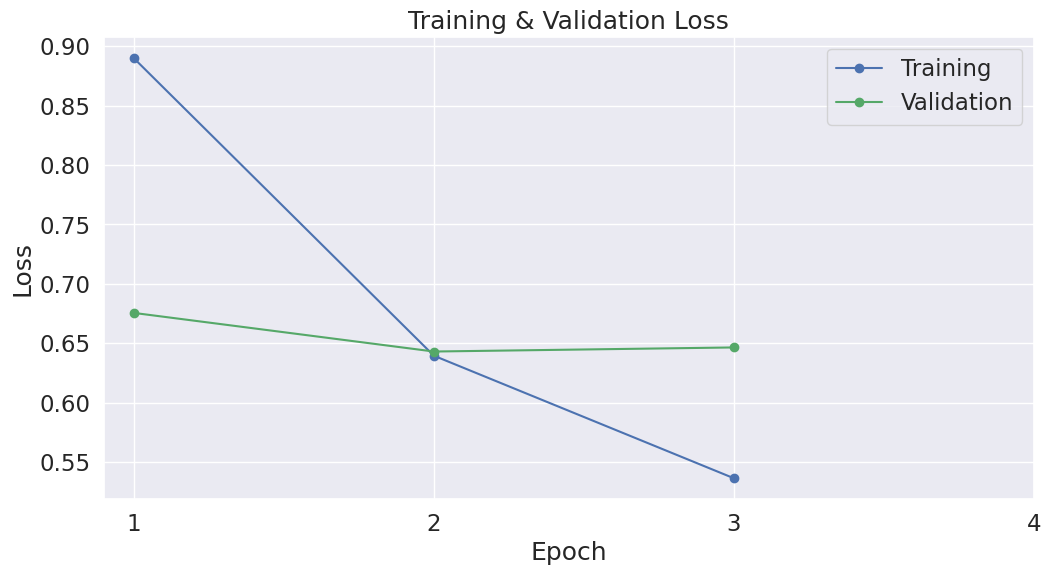

In [ ]:
import matplotlib.pyplot as plt
#% matplotlib inline

import seaborn as sns

# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(df_stats['Training Loss'], 'b-o', label="Training")
plt.plot(df_stats['Valid. Loss'], 'g-o', label="Validation")

# Label the plot.
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.xticks([1, 2, 3, 4])

plt.show()

Вывод:

Для ускорения обучения использована выборка из 3000 отзывов. График демонстрирует успешное обучение модели - Training Loss резко снижается на протяжении всех эпох. Validation Loss падает между 1 и 2 эпохой, после чего стабилизируется и начинает незначительно расти.

Оптимальное количество эпох -  2, так как дальнейшее обучение ведет к переобучению: модель начинает заучивать конкретные фразы из тренировочных данных вместо выделения общих признаков тональности.